Built a GARCH(1,1) volatility model on 18 years of real S&P 500 data (2007–2026) in Python. The orange band is the model's 95% daily-move range Notice how it pinches tight in calm years and explodes during 2008 and 2020. That "breathing" is volatility clustering: turbulence comes in bursts, not randomly. First step into quantitative finance, and it won't be the last.

In [1]:
!pip install yfinance arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.2 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

In [3]:
data = yf.download("^GSPC", start="2007-01-01", end="2026-01-12")
data.tail()

/tmp/ipykernel_2333/2737616248.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2007-01-01", end="2026-01-12")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2026-01-05,6902.049805,6920.379883,6891.560059,6892.189941,5771930000
2026-01-06,6944.819824,6948.689941,6904.020020,6908.029785,5509680000
2026-01-07,6920.930176,6965.689941,6919.189941,6945.069824,5214480000
2026-01-08,6921.459961,6931.279785,6899.330078,6914.109863,5333200000
2026-01-09,6966.279785,6978.359863,6917.640137,6927.830078,5163900000


In [4]:
returns = 100 * data["Close"].pct_change().dropna()
returns.tail()

Ticker,^GSPC
Date,
2026-01-05,0.635413
2026-01-06,0.619671
2026-01-07,-0.343992
2026-01-08,0.007655
2026-01-09,0.647549


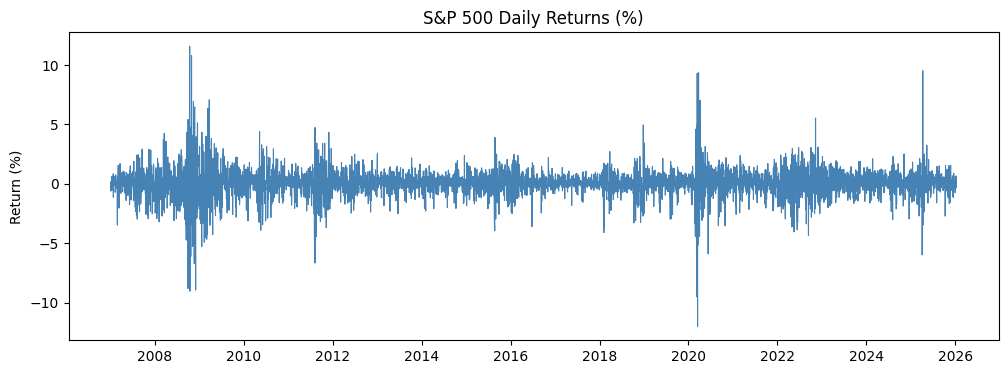

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(returns, color="steelblue", linewidth=0.8)
plt.title("S&P 500 Daily Returns (%)")
plt.ylabel("Return (%)")
plt.show()

In [6]:
model = arch_model(returns, vol="Garch", p=1, q=1, mean="Constant", dist="normal")
result = model.fit(disp="off")

In [7]:
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6541.01
Distribution:                  Normal   AIC:                           13090.0
Method:            Maximum Likelihood   BIC:                           13115.9
                                        No. Observations:                 4785
Date:                Sat, Jun 13 2026   Df Residuals:                     4784
Time:                        07:43:28   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0773  1.147e-02      6.735  1.643e-11 [5.

In [8]:
volatility = result.conditional_volatility
volatility.tail()

,cond_vol
Date,
2026-01-05,0.652783
2026-01-06,0.656824
2026-01-07,0.658341
2026-01-08,0.647048
2026-01-09,0.618109


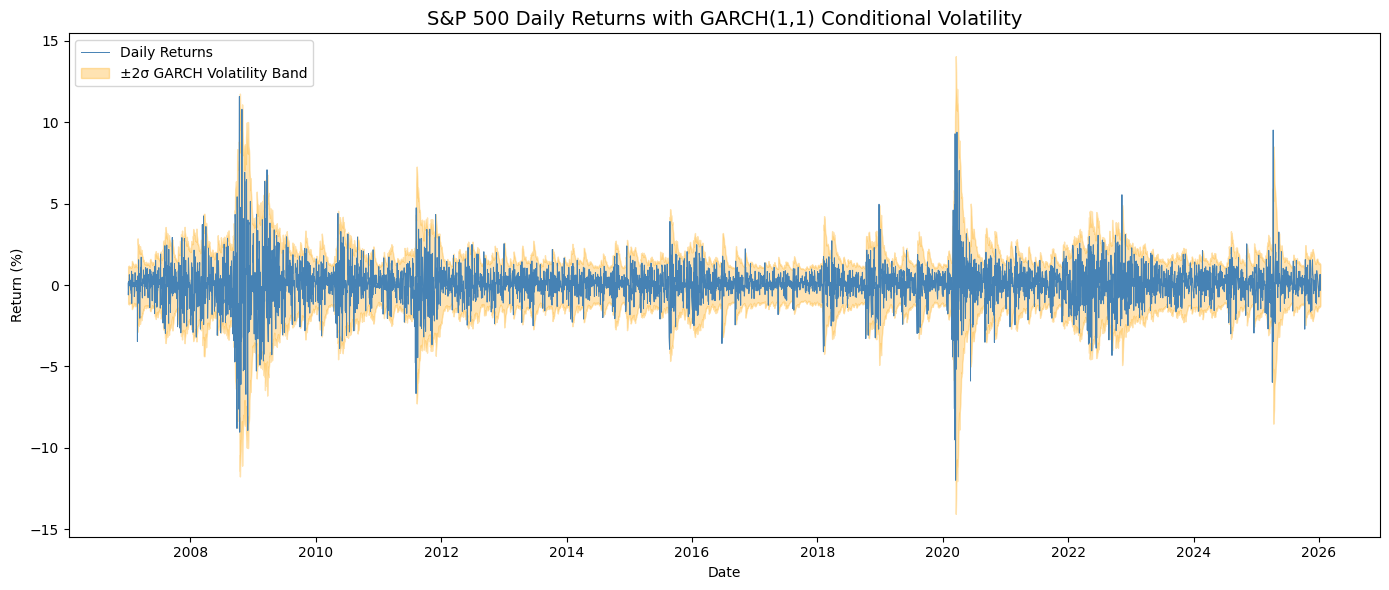

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(returns, color="steelblue", linewidth=0.7, label="Daily Returns")

plt.fill_between(returns.index, -2*volatility, 2*volatility,
                 color="orange", alpha=0.3, label="±2σ GARCH Volatility Band")

plt.title("S&P 500 Daily Returns with GARCH(1,1) Conditional Volatility", fontsize=14)
plt.ylabel("Return (%)")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("sp500_garch.png", dpi=150)
plt.show()

In [11]:

window = 120
n      = len(r)
frames = list(range(0, n - window, max(1, (n - window) // 180)))  # ~180 frames

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0a0e17")

def update(start):
    ax.clear()
    ax.set_facecolor("#070a11")
    end = start + window
    xs  = dates[start:end]
    rs  = r[start:end]
    vs  = v[start:end]

    ax.fill_between(xs, -2*vs, 2*vs, color="#2dd4bf", alpha=0.18)
    ax.plot(xs,  2*vs, color="#2dd4bf", linewidth=1.2)
    ax.plot(xs, -2*vs, color="#2dd4bf", linewidth=1.2)
    ax.vlines(xs, 0, rs, color="#6ea8fe", linewidth=1.0, alpha=0.7)
    ax.axhline(0, color="white", alpha=0.15, linewidth=0.8)

    ax.set_ylim(-12, 12)
    ax.set_ylabel("Return (%)", color="#8b97a7")
    ax.tick_params(colors="#5f6b7c", labelsize=8)
    for s in ax.spines.values():
        s.set_color("#1c2433")
    ax.set_title("GARCH(1,1) conditional volatility  ·  S&P 500  ·  "
                 + xs[-1].strftime("%b %Y"),
                 color="#e6edf3", fontsize=13, loc="left")
    return []

anim = FuncAnimation(fig, update, frames=frames, blit=False)
anim.save("garch_animation.gif", writer=PillowWriter(fps=20))
plt.close(fig)

from google.colab import files
print("Done. Right-click the files in the left sidebar to download,")
print("or run the two lines below to download directly:")
files.download("garch_animation.gif")
files.download("sp500_garch_static.png")

Done. Right-click the files in the left sidebar to download,
or run the two lines below to download directly:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>